# Attribution Patching — Extension Results

## Team-member contribution

**Noorish Hassan and Sirisha Sandadi** developed the attribution-patching
extension for the arithmetic GPT-2 model. The implementation is located in
`src/attribution_patching.py`.

The extension:

- constructs controlled base–source intervention pairs;
- caches attention-head and MLP activations;
- computes gradient-times-activation-difference attribution scores;
- ranks candidate attention heads and MLPs; and
- generates result files and attribution heatmaps.

This notebook does not rerun the attribution-patching experiment. It explains
the implementation and loads the precomputed outputs for visualization and
interpretation.

LLMs were used to polish parts of the documentation.

## Component-level screening for arithmetic representations in GPT-2

This notebook presents the attribution-patching part of our extension to **Pîslar, Magliacane & Geiger (CLeaR 2025)**.

The original work uses Distributed Alignment Search (DAS) to test whether high-level causal variables, such as the partial sum $X+Y$, align with neural representations. We proposed attribution patching as a computationally inexpensive screening step to identify individual attention heads and MLPs that are promising candidates for more expensive causal testing with Per-Node DAS.

A high attribution score is interpreted as evidence that changing a component from its base activation toward its source activation is locally predicted to move the model toward the counterfactual source answer. It is **not**, by itself, proof that the component independently computes the targeted variable. Attribution Patching itself is only an **approximation**

## Method

For a base activation $a_b$, source activation $a_s$, and output metric $M$, attribution patching uses the first-order approximation

$$
\Delta M \approx \nabla_{a_b}M \cdot (a_s-a_b).
$$

The metric used here is

$$
M = \operatorname{logit}(O_{source})-\operatorname{logit}(O_{base}).
$$

Positive signed attribution therefore predicts that replacing the base activation with the source activation would push the model toward the source answer. 

In [1]:
import json
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd

# The notebook is expected to be located in project_root/notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CONFIG = SimpleNamespace(
    attributes=("x", "y", "z", "xy", "yz", "xz", "xyz"),
    results_dir=PROJECT_ROOT / "results" ,
)

if not CONFIG.results_dir.is_dir():
    raise FileNotFoundError(
        "Attribution-patching results were not found at:\n"
        f"{CONFIG.results_dir}\n\n"
        "Run src/attribution_patching.py separately or copy the existing "
        "result files into that directory."
    )

print("Project root:", PROJECT_ROOT)
print("Reading results from:", CONFIG.results_dir)

Project root: /Users/ssirisha/Desktop/attribute-patching-clean-test/automated-causal-abstraction
Reading results from: /Users/ssirisha/Desktop/attribute-patching-clean-test/automated-causal-abstraction/results


In [2]:
def load_result(attribute):
    path = CONFIG.results_dir / f"atp_{attribute}" / f"atp_arithmetic_{attribute}.json"

    if not path.is_file():
        raise FileNotFoundError(
            f"Missing result file for attribute '{attribute}':\n{path}"
        )

    with path.open("r", encoding="utf-8") as file:
        result = json.load(file)

    required_keys = {
        "model_name",
        "attribute",
        "head_scores",
        "head_abs_scores",
        "mlp_scores",
        "mlp_abs_scores",
        "top_heads",
        "top_mlps",
    }

    missing = required_keys.difference(result)
    if missing:
        raise KeyError(
            f"{path.name} is missing required fields: {sorted(missing)}"
        )

    return result


attribution_results = {
    attribute: load_result(attribute)
    for attribute in CONFIG.attributes
}

print("Loaded result files:")
for attribute, result in attribution_results.items():
    print(
        f"- {attribute}: model={result['model_name']}, "
        f"pairs={result.get('num_pairs', 'unknown')}"
    )

Loaded result files:
- x: model=mara589/arithmetic-gpt2, pairs=128
- y: model=mara589/arithmetic-gpt2, pairs=128
- z: model=mara589/arithmetic-gpt2, pairs=128
- xy: model=mara589/arithmetic-gpt2, pairs=128
- yz: model=mara589/arithmetic-gpt2, pairs=128
- xz: model=mara589/arithmetic-gpt2, pairs=128
- xyz: model=mara589/arithmetic-gpt2, pairs=128


## Base–source pairs

For each intervention type, only the selected arithmetic variables are changed:

- `x`: change $X$
- `y`: change $Y$
- `z`: change $Z$
- `xy`: change $X$ and $Y$, while keeping $Z$ fixed
- `yz`: change $Y$ and $Z$, while keeping $X$ fixed
- `xz`: change $X$ and $Z$, while keeping $Y$ fixed

For the `xy` condition, the counterfactual target is the source partial sum ($P$=$X$+$Y$) combined with the unchanged base value of $Z$ ($O$=$P$+$Z$)

## How the source experiment constructs interventions

The implementation in `src/attribution_patching.py` randomly samples a
base expression

\[
X + Y + Z
\]

and constructs a source expression by changing only the variables
associated with the selected intervention.

For example:

| Intervention | Base | Source | Fixed |
|---|---|---|---|
| `x` | `2+4+7=` | `8+4+7=` | \(Y,Z\) |
| `y` | `2+4+7=` | `2+8+7=` | \(X,Z\) |
| `z` | `2+4+7=` | `2+4+3=` | \(X,Y\) |
| `xy` | `2+4+7=` | `8+1+7=` | \(Z\) |

Pairs for which the base and source totals are equal are discarded,
because they would not define a changed output target.

## Cache attention-head and MLP activations

For each GPT-2 block, we cache:

1. the input to `attn.c_proj`, which contains the concatenated outputs of all attention heads before output projection;
2. the output of the block's MLP.

The attention tensor is reshaped into separate head dimensions before computing per-head attribution.

### Activation locations used by the implementation

The source code registers hooks at two locations in every GPT-2 block:

1. **Input to `attn.c_proj`**  
   This tensor contains the concatenated attention-head outputs before
   the attention output projection. It can therefore be reshaped into
   separate head dimensions.

2. **Output of the MLP**  
   This captures the contribution produced by the feed-forward
   sublayer at each transformer layer.

For the source prompt, these activations are cached without gradients.
For the base prompt, they are cached while retaining gradients of the
output metric.

## How attribution scores are computed

For each batch, the source implementation performs one forward pass on the
source prompts and one forward pass on the base prompts.

### 1. Source forward pass

The model processes the source prompts and caches the corresponding attention
and MLP activations. This pass is executed without gradient tracking because the source activations
are only used as reference values for the hypothetical patch.

### 2. Base forward pass

The model then processes the base prompts and computes the output metric. The implementation retains the gradient of this metric with respect to each
cached base activation.

### 3. First-order patch estimate

For each attention head or MLP component, attribution patching estimates the
effect of replacing the base activation with the corresponding source
activation. The resulting values are summed over the batch, token positions, and hidden
dimensions. For attention outputs, the hidden dimension is first separated
into individual attention heads so that each head receives its own score.

Two score variants are stored:

- **Signed attribution score:** estimates whether the activation change pushes
  the model toward or away from the source output.
- **Absolute attribution score:** measures the total magnitude of the estimated
  effect and is used to rank candidate attention heads and MLP layers.

These scores are first-order approximations. A large attribution score
identifies a candidate component for further causal validation, but does not
by itself prove that the component implements the corresponding arithmetic
quantity.

In [3]:
summary_rows = []

for attribute, result in attribution_results.items():
    head_scores = np.asarray(result["head_abs_scores"])
    mlp_scores = np.asarray(result["mlp_abs_scores"])

    summary_rows.append({
        "attribute": attribute,
        "num_pairs": result.get("num_pairs"),
        "batch_size": result.get("batch_size"),
        "metric_mean": result.get("metric_mean"),
        "num_layers": head_scores.shape[0],
        "heads_per_layer": head_scores.shape[1],
        "max_head_attribution": float(head_scores.max()),
        "max_mlp_attribution": float(mlp_scores.max()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,attribute,num_pairs,batch_size,metric_mean,num_layers,heads_per_layer,max_head_attribution,max_mlp_attribution
0,x,128,8,-12.491670,12,12,2.823828,25.371317
1,y,128,8,-12.460218,12,12,2.531535,24.082241
2,z,128,8,-12.495738,12,12,1.767438,23.619825
3,xy,128,8,-13.457854,12,12,3.089063,27.664291
4,yz,128,8,-13.641679,12,12,2.764941,26.615107
5,xz,128,8,-13.718684,12,12,2.663632,26.973700
6,xyz,128,8,-13.495042,12,12,3.449703,31.822786


The mean metric is negative because it is measured on the unpatched base
prompt. A correctly classified base example should assign a higher logit to
the base answer than to the source answer. Attribution patching estimates
which activation changes would increase this metric toward the source answer.

## Load the precomputed attribution-patching experiments

The following result files were generated separately by
`src/attribution_patching.py`.

This notebook reads those files but does not rerun attribution patching.

## Results: attention-head attribution maps

Rows correspond to transformer layers and columns correspond to attention heads. The heatmaps show **absolute** attribution magnitude, which is useful for screening but does not indicate the direction of the predicted effect.

X intervention


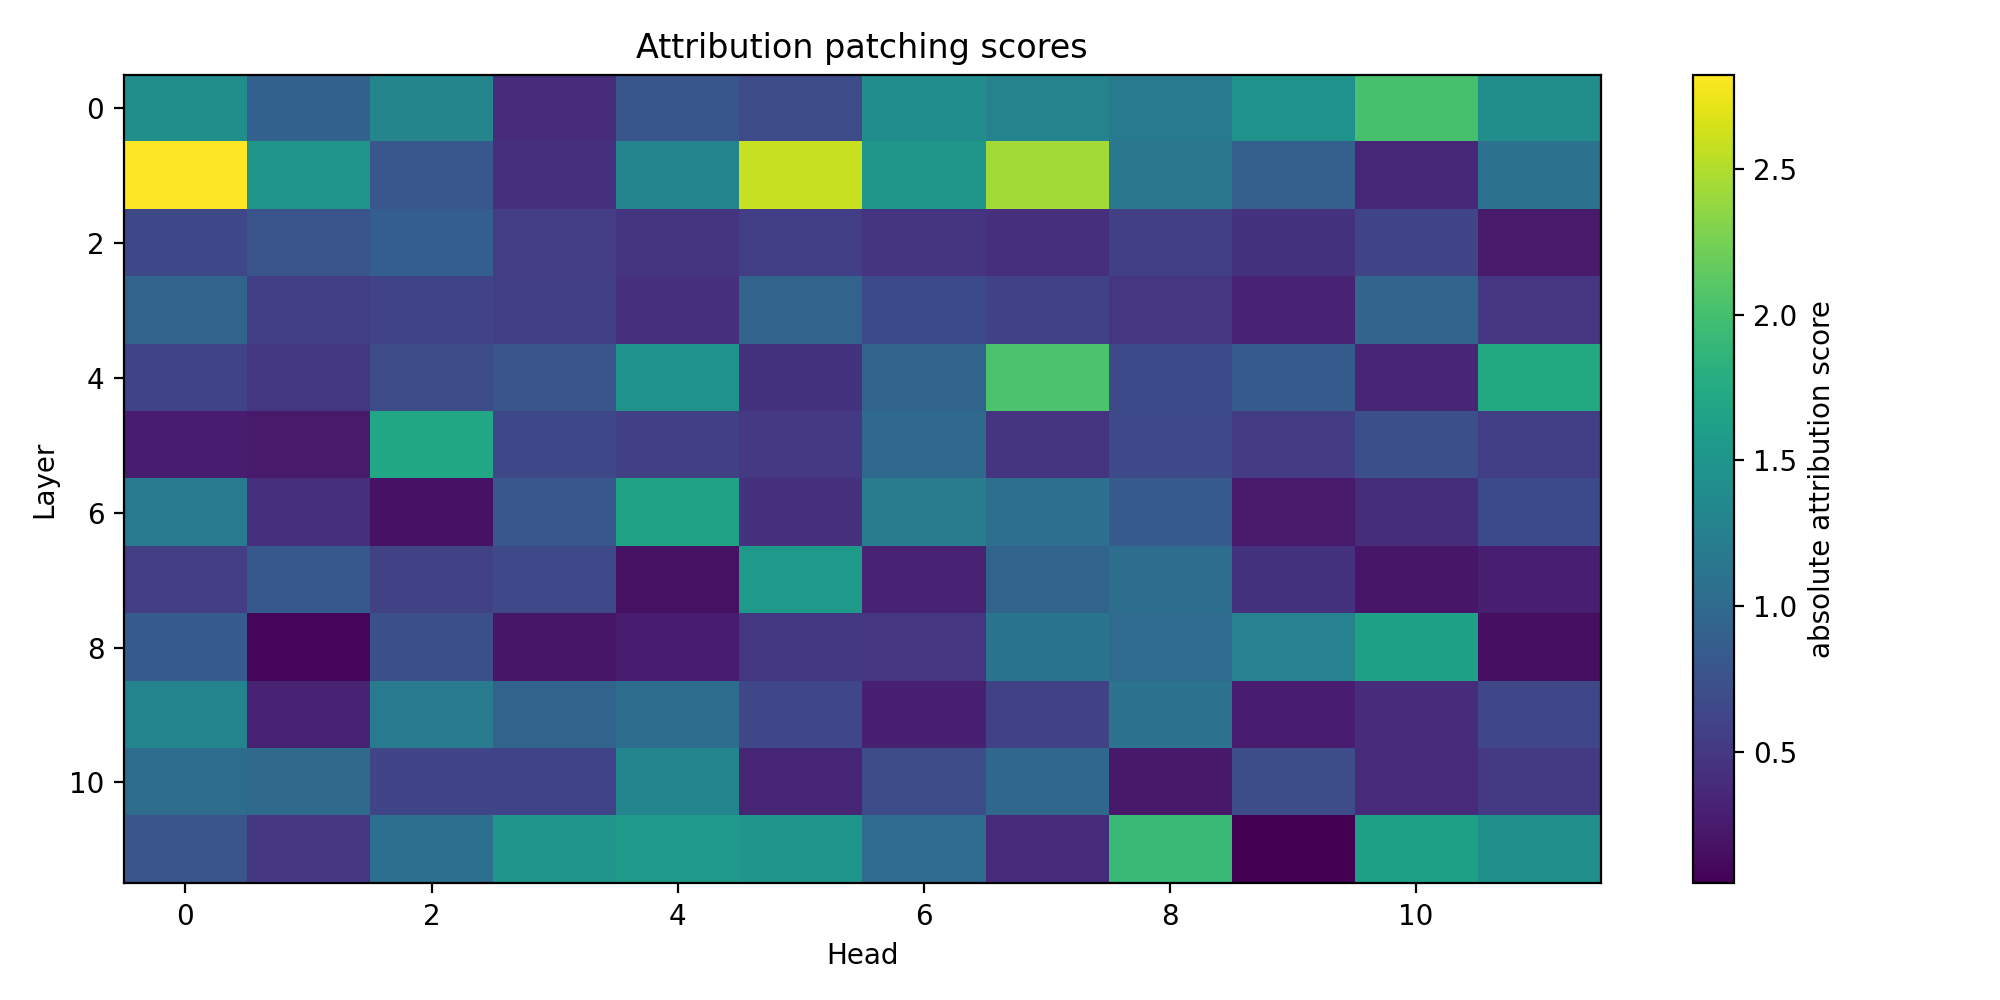

Y intervention


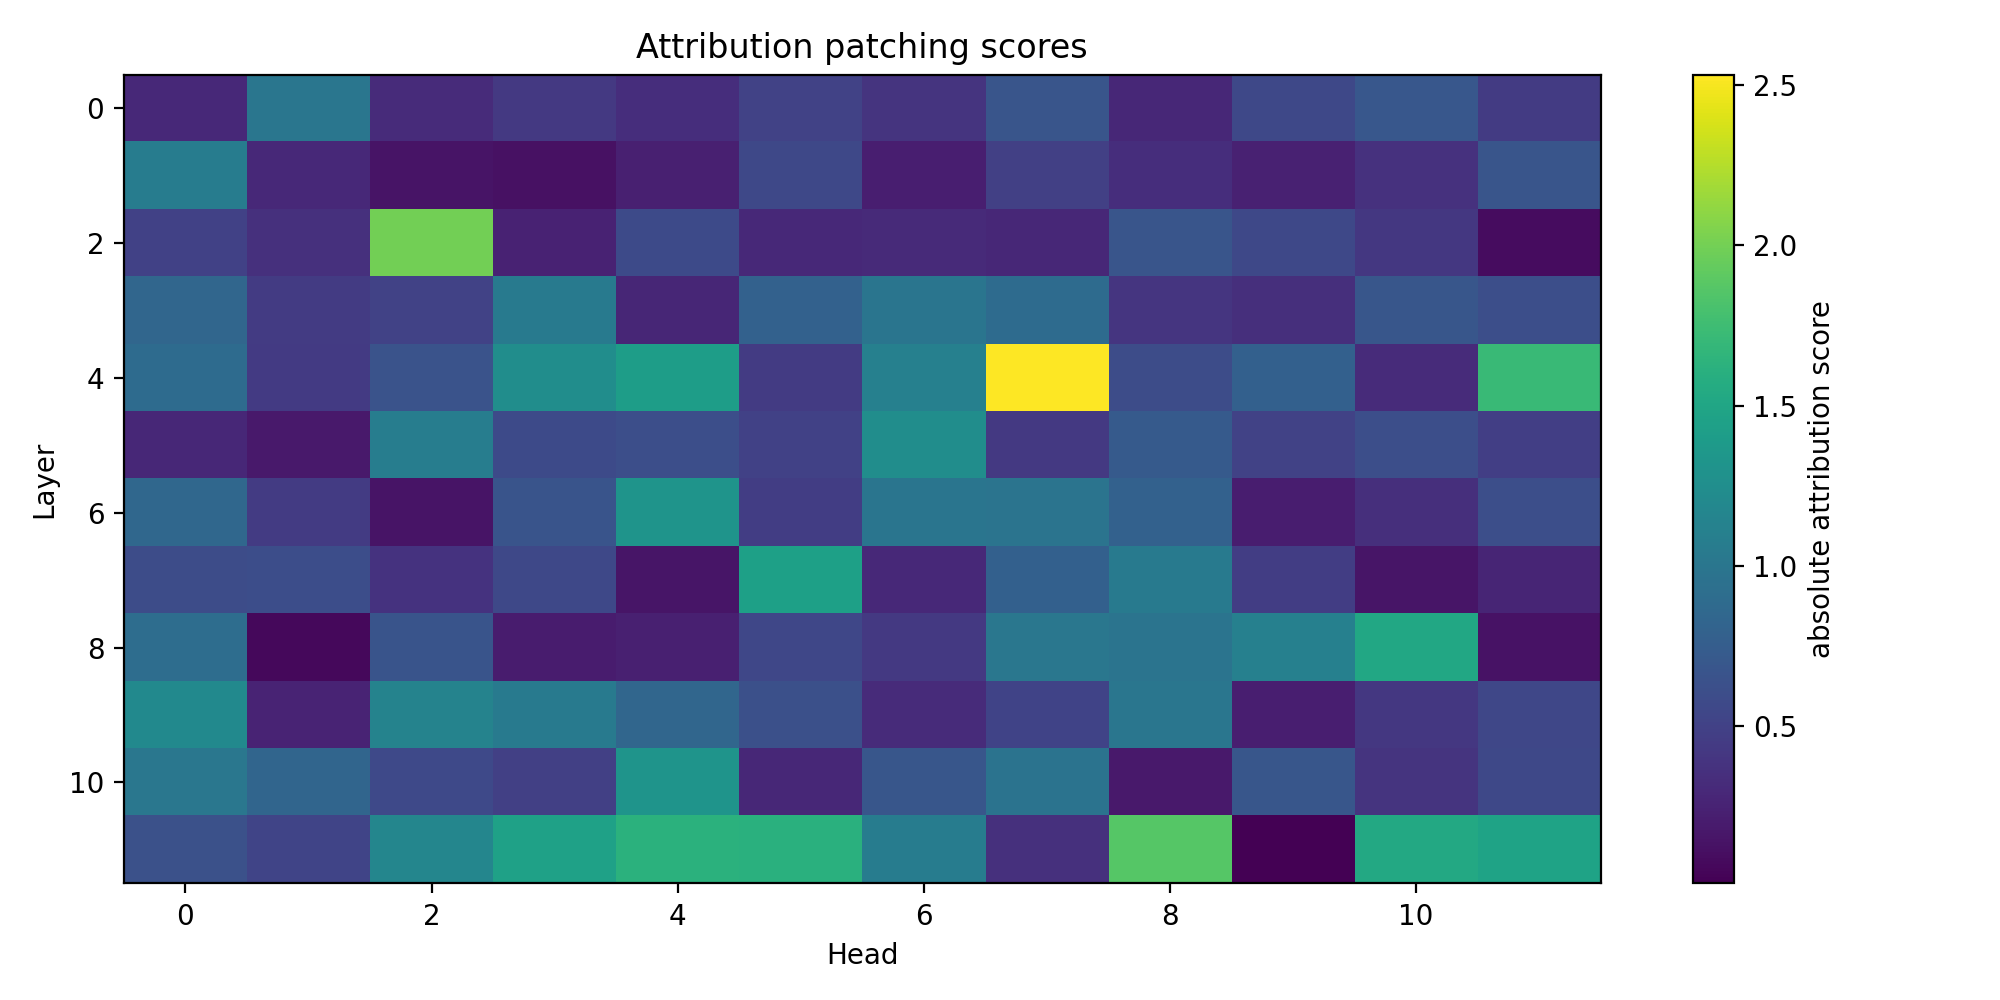

Z intervention


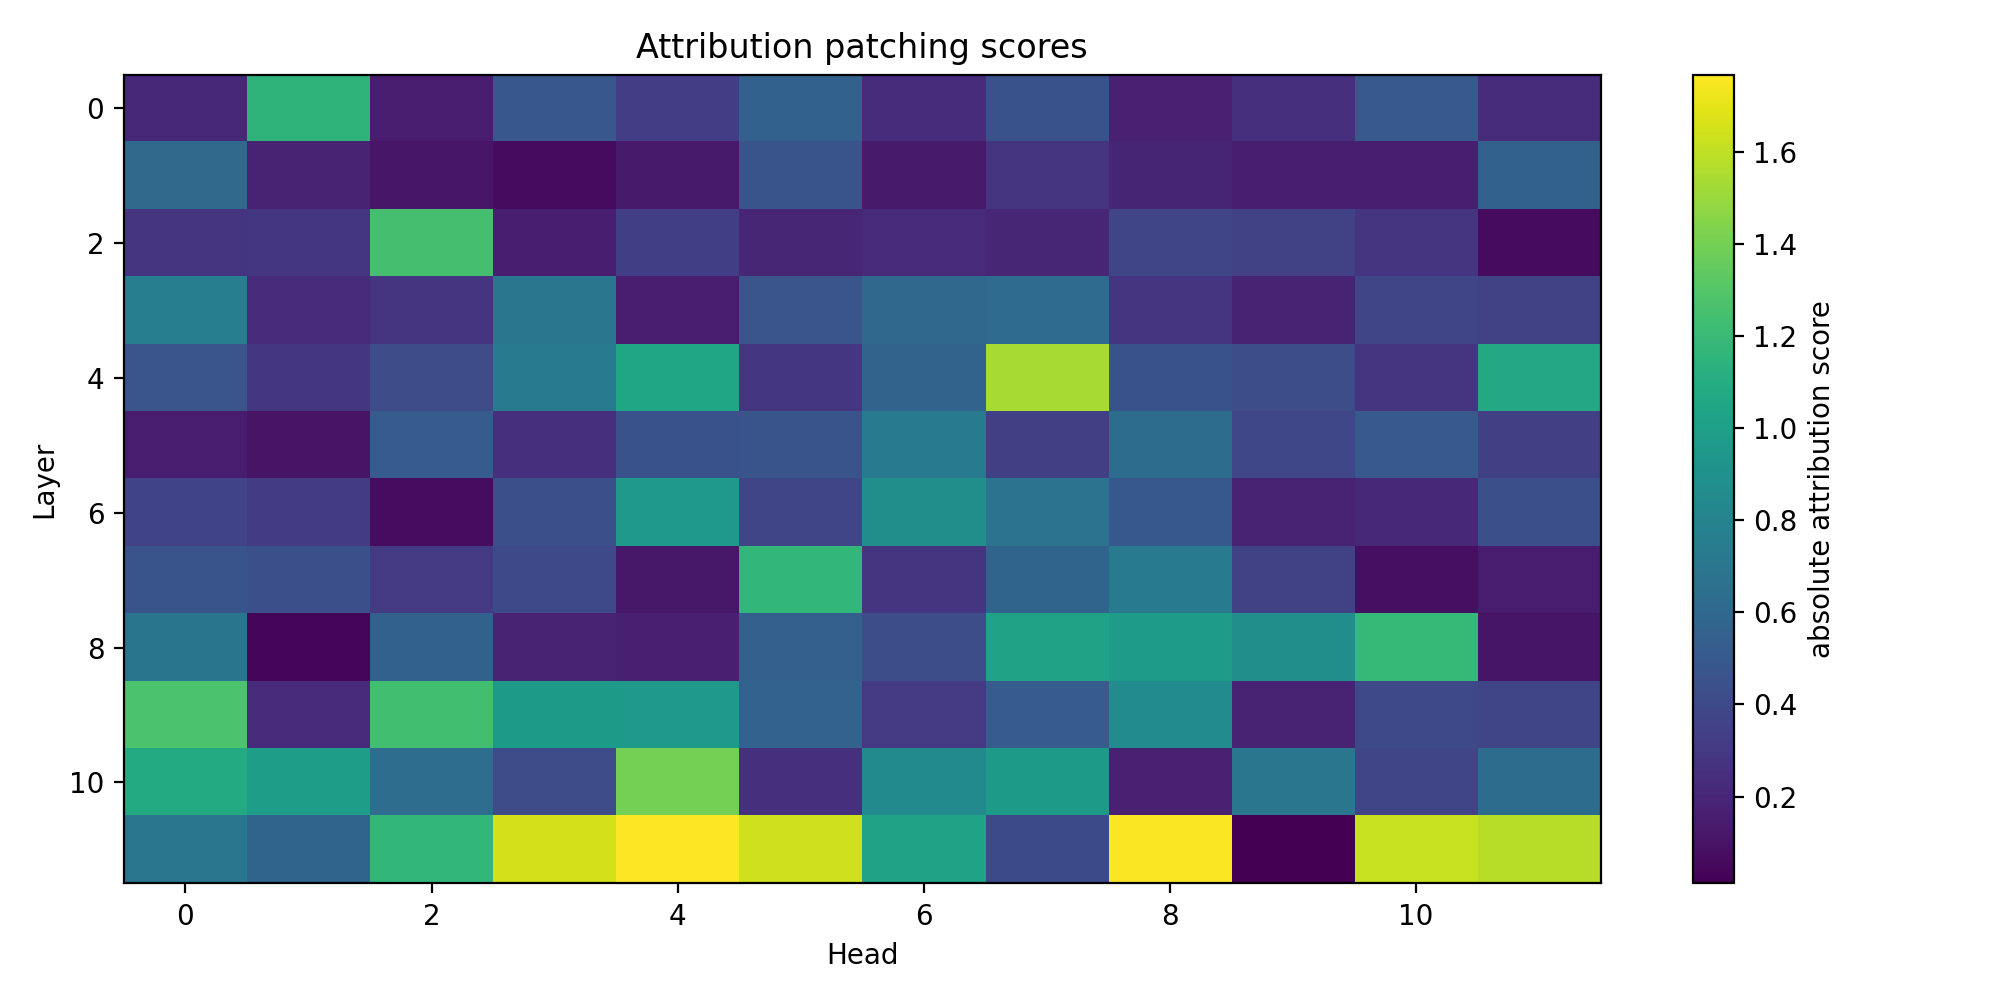

XY intervention


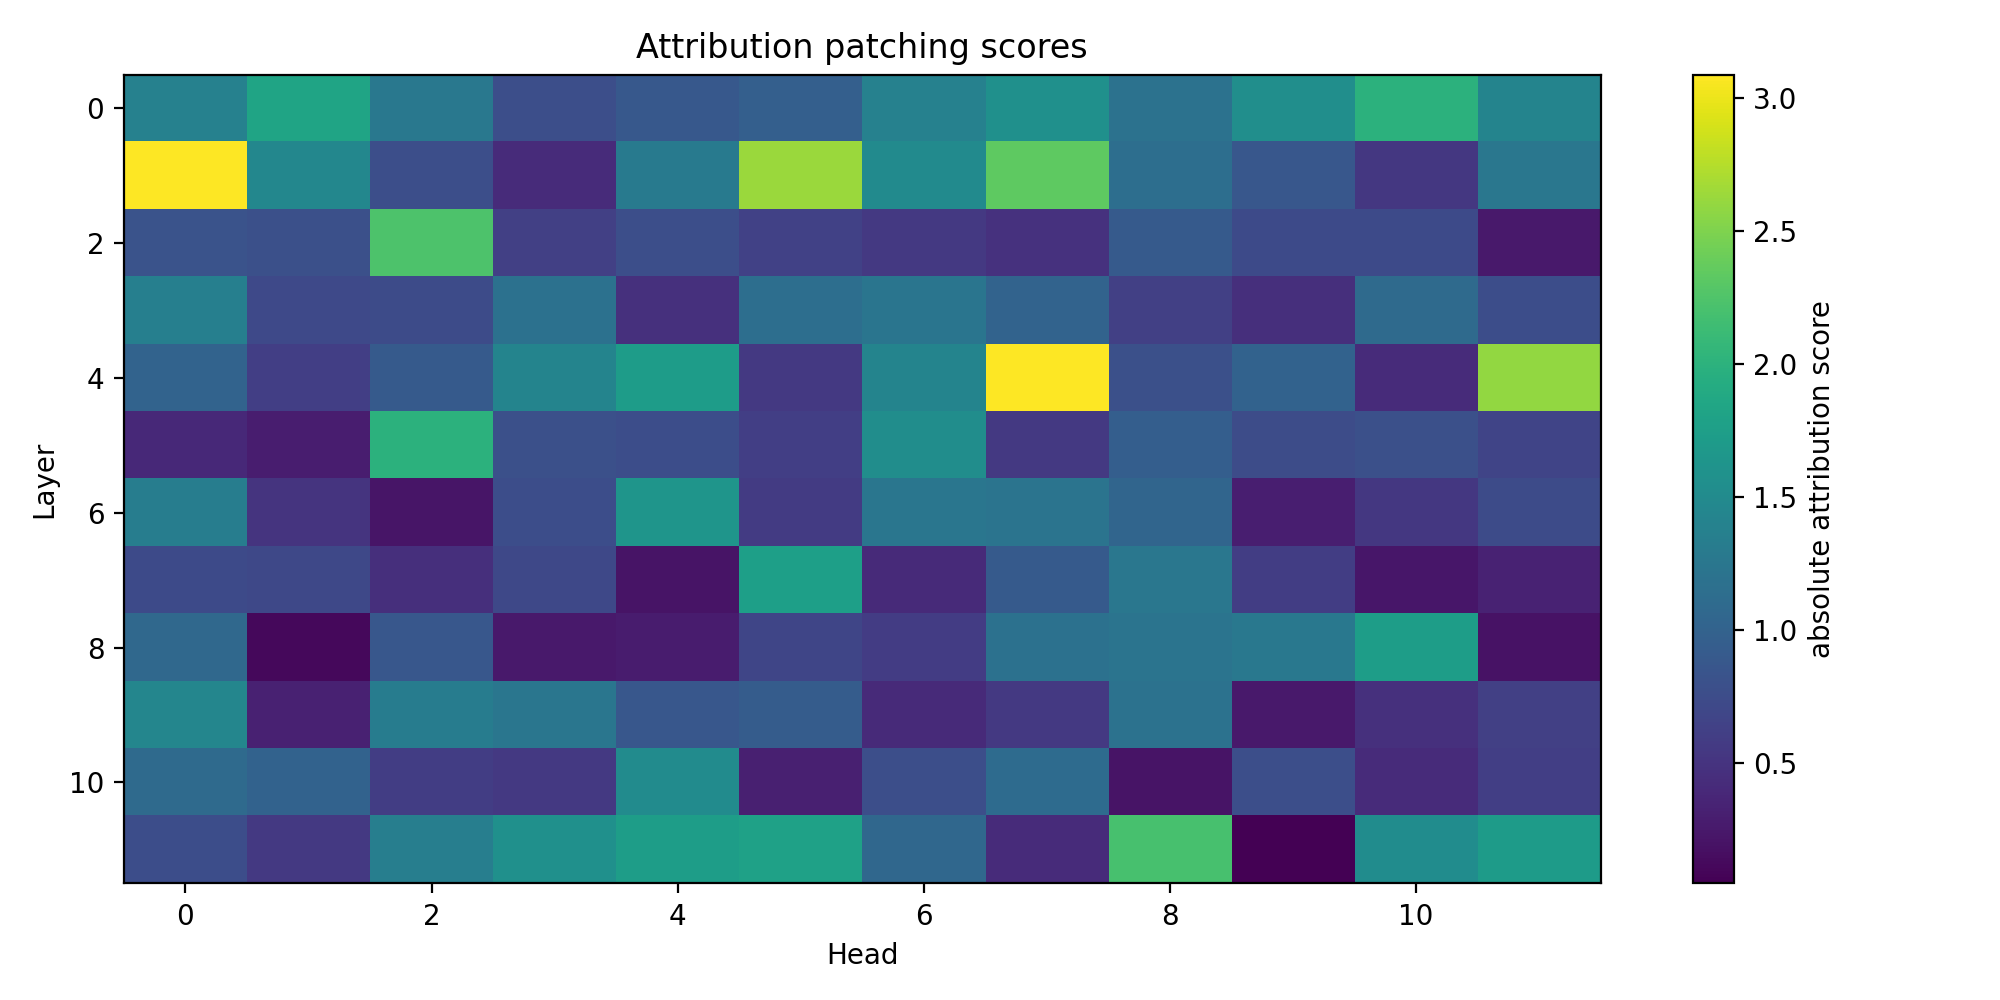

YZ intervention


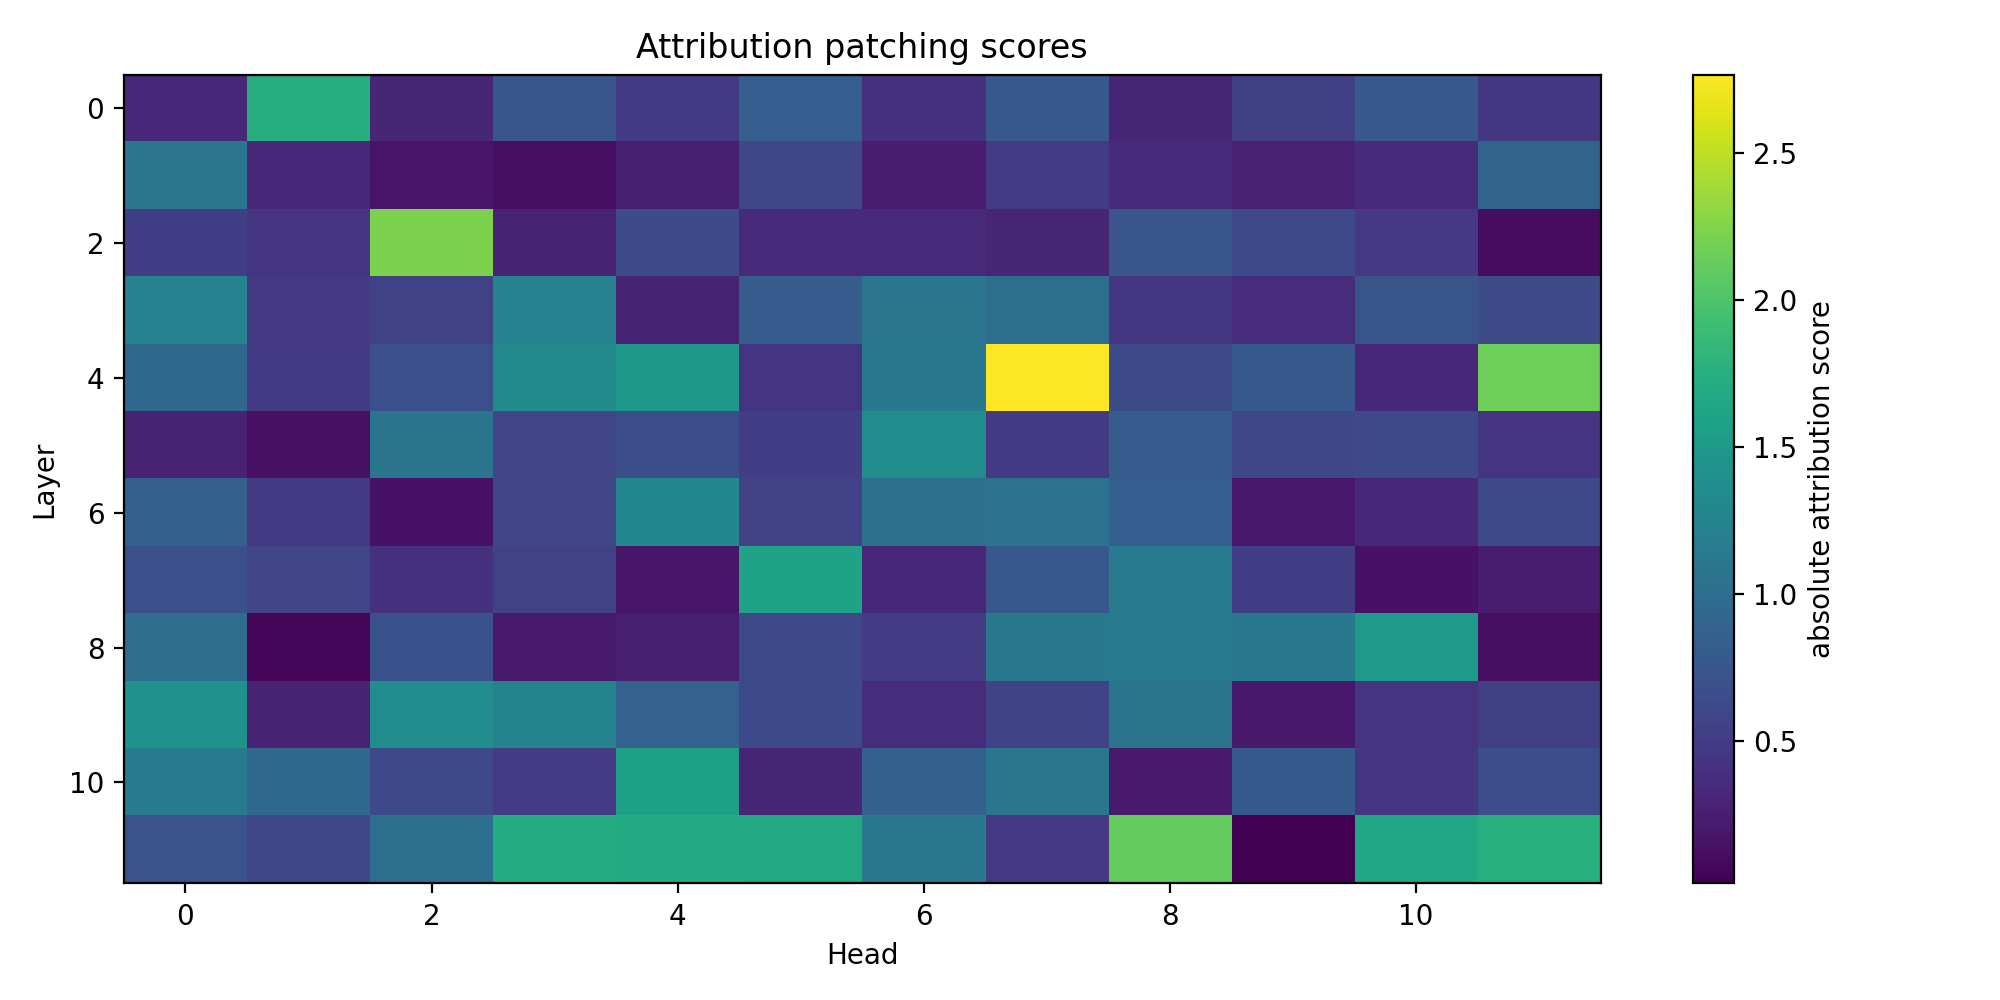

XZ intervention


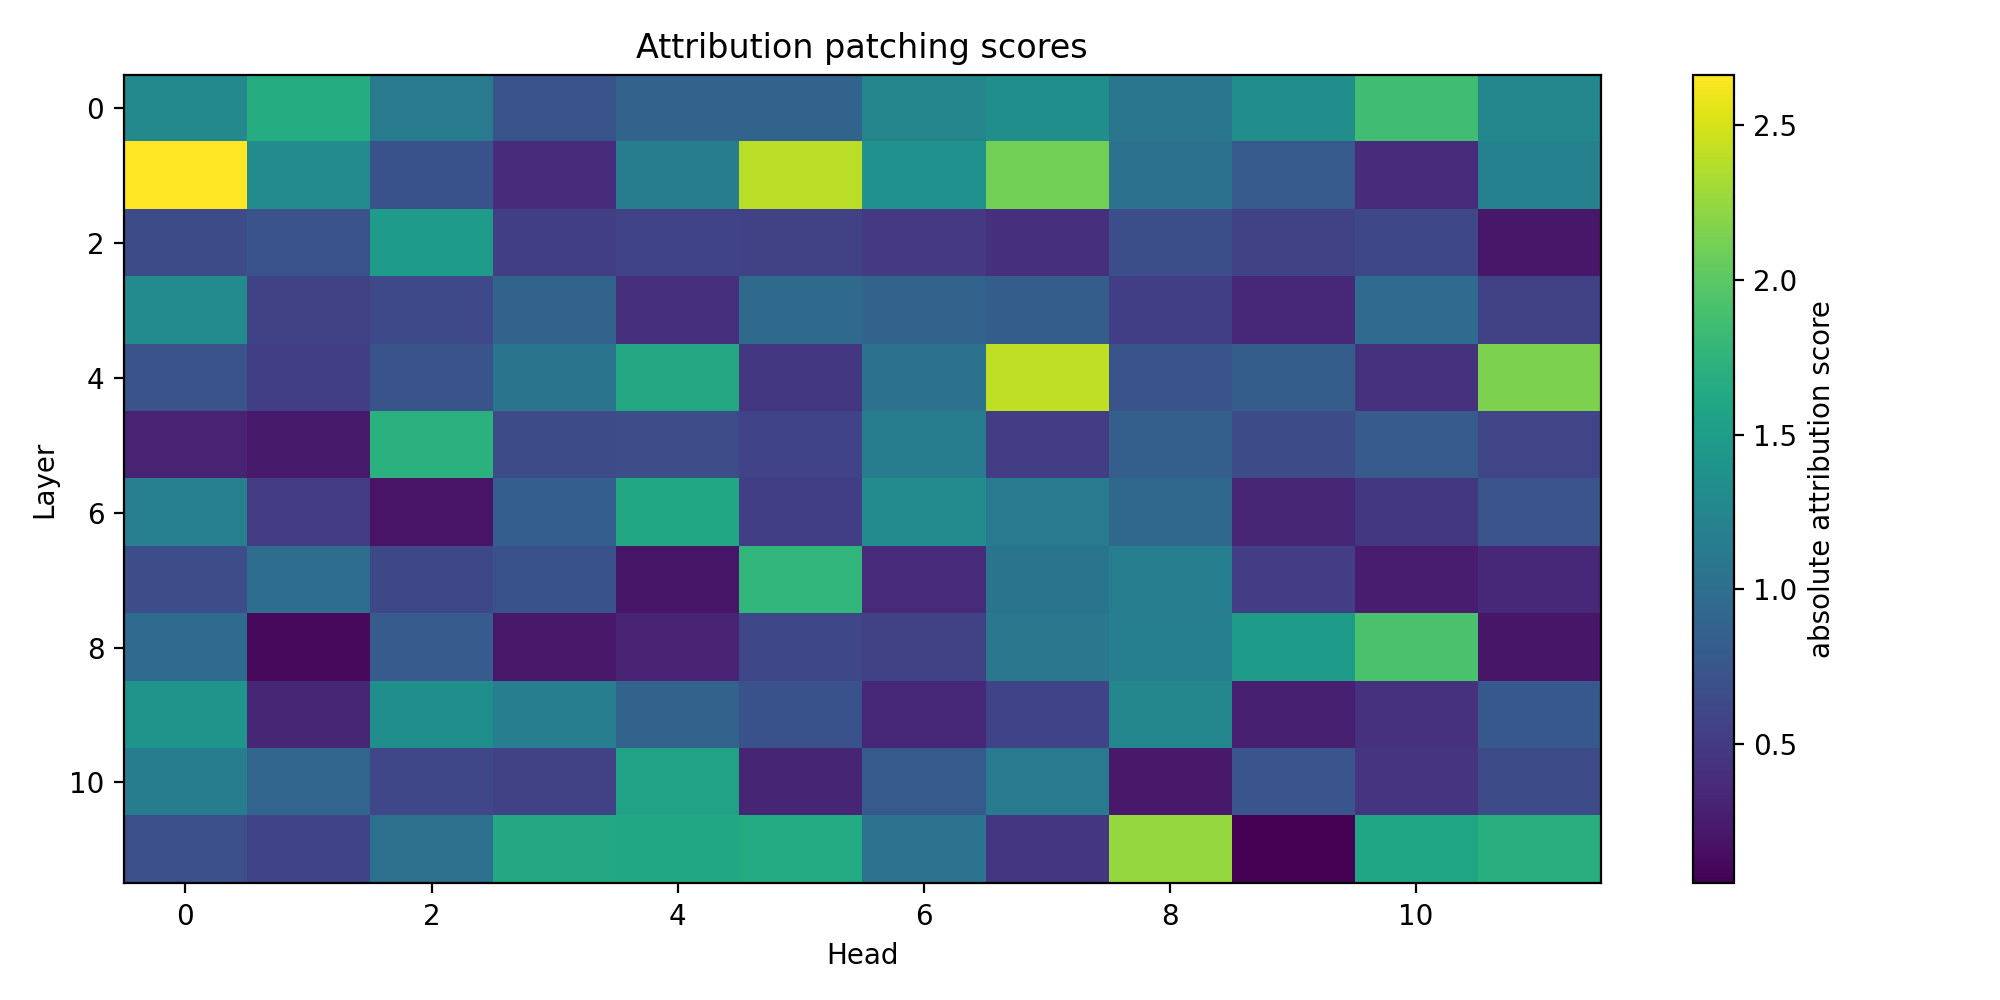

XYZ intervention


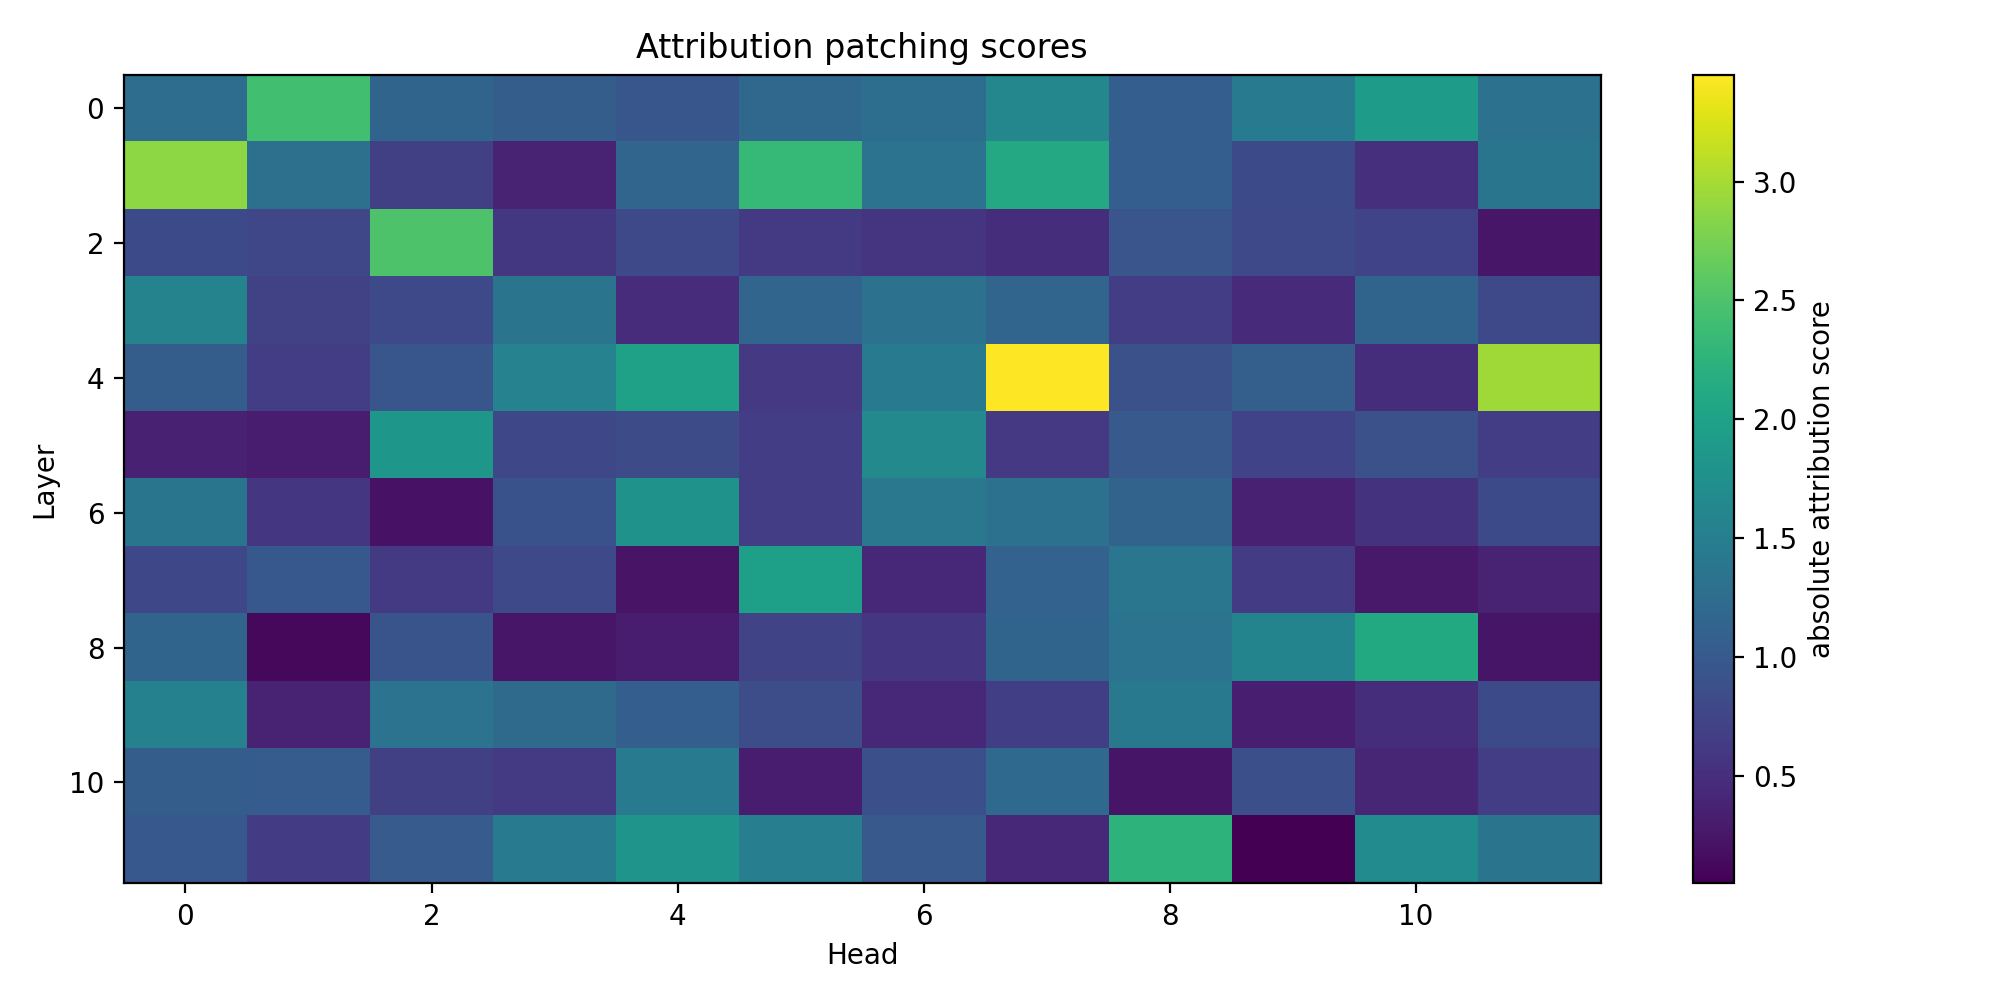

In [4]:
from IPython.display import display, Image

for attribute in CONFIG.attributes:
    image_path = (
        CONFIG.results_dir
        / f"atp_{attribute}"/ f"atp_arithmetic_{attribute}_heads.png"
    )

    if image_path.is_file():
        print(f"{attribute.upper()} intervention")
        display(Image(filename=str(image_path)))
    else:
        print(f"Missing heatmap: {image_path}")

## Ranked candidate components

These rankings identify components for subsequent causal validation. Because absolute scores are used, a highly ranked component may have either a positive or negative signed contribution.

In [5]:
head_tables = []

for attribute, result in attribution_results.items():
    signed = np.asarray(result["head_scores"])
    rows = []

    for item in result["top_heads"][:10]:
        layer = item["layer"]
        head = item["head"]
        rows.append({
            "attribute": attribute,
            "layer": layer,
            "head": head,
            "absolute_score": item["score"],
            "signed_score": float(signed[layer, head]),
        })

    head_tables.append(pd.DataFrame(rows))

top_heads_df = pd.concat(head_tables, ignore_index=True)
top_heads_df

,attribute,layer,head,absolute_score,signed_score
0,x,1,0,2.823828,0.395424
1,x,1,5,2.586174,0.249297
2,x,1,7,2.436010,0.379897
3,x,4,7,2.039948,-0.158293
4,x,0,10,2.017148,0.088241
...,...,...,...,...,...
65,xyz,1,5,2.320408,-0.056130
66,xyz,11,8,2.245814,0.463155
67,xyz,8,10,2.108758,-0.089808
68,xyz,1,7,2.094565,-0.145240


In [ ]:
mlp_tables = []

for attribute, result in attribution_results.items():
    signed = np.asarray(result["mlp_scores"])
    rows = []

    for item in result["top_mlps"][:5]:
        layer = item["layer"]
        rows.append({
            "attribute": attribute,
            "layer": layer,
            "absolute_score": item["score"],
            "signed_score": float(signed[layer]),
        })

    mlp_tables.append(pd.DataFrame(rows))

top_mlps_df = pd.concat(mlp_tables, ignore_index=True)
top_mlps_df

,attribute,layer,absolute_score,signed_score
0,x,10,25.371317,3.289998
1,x,11,21.714447,9.390046
2,x,9,19.704025,1.704351
3,x,0,19.114355,1.671201
4,x,8,18.510300,1.069983
5,y,10,24.082241,3.229593
6,y,11,21.584997,9.557492
7,y,9,18.662201,1.597721
8,y,8,17.328959,0.868446
9,y,7,13.647043,0.251476


## Interpretation

The attribution maps test whether arithmetic-related activation differences are concentrated in a small subset of components. If only a few heads receive large scores, this provides a sparse list of candidate components rather than evidence for a complete arithmetic circuit.

Differences between the `x`, `z`, `xy`, and `yz` maps suggest that different arithmetic variables may rely on partly different internal components. These candidates can then be tested using Per-Node DAS and Interchange Intervention Accuracy.

Because attribution patching is only a first-order approximation, exact
activation patching would be a useful follow-up validation step. Exact
patching was not performed in this walkthrough.

## Limitations

1. Attribution patching is a local linear **approximation** and may be inaccurate for large interventions.
2. Absolute attribution measures magnitude, not whether a component helps or opposes the counterfactual prediction.
3. A high score does not establish that a head is independently necessary or sufficient.
4. The experiment identifies candidate components, not the connections between them, so it does not constitute full circuit discovery.
5. Results are based on one generated sample and one seed unless the experiment is repeated across seeds.
6. Scores depend on the chosen output metric and should not be compared across experiments without care.
7. Exact patching of individual top heads is only a sanity check; full validation would require broader component, path, and combination tests.

Sample command to run the `attribution_patching.py` file 
```bash
python src/attribution_patching.py \
  --attribute xy \
  --num_pairs 128 \
  --batch_size 8 \
  --seed 1 \
  --output_root results/atp_xy_1
```